# RG1 Gene Expression Model Creation

Previously, we were able to deconvolve the chromatin and gene expression for CLB2 from Yulong's replicate 2 data set. However, we previously discussed that this dataset, because it uses an alpha factor arrest, may need to have a different way to represent the recovery phase of the cell cycle. 

Rather than use the Recovery, CG1, postG1 phases to represent the initial branch. We will switch to the RG1, postG1 phases for these cells. The motivation is that, these cells that are recoverying from alpha factor, are continuing to recover through their own special version of G1 that will be distinct from the Common (Mother) G1 cells and the Daughter G1 cells.

So the tasks will be:
1. We will need to decide if we are using 2 or 3 Wavelets.
    - The original model used two wavelets, one for initial and top combined, and the second for the bottom branch. Let's try this for this model for now, and see how it fits. This will reduce the complexity of needing another factor to balance between a third wavelet.
    - The concern may be that we will be duplicating postG1 multiple times in this first smoothing constraint.
3. Create the model file for RG1. We have one already, but we should update the time points to be a power of two when we combine the initial and top branches, and make sure the bottom branch is a power of two for the wavelet.
4. Then, we should be able to deconvolve and evaluate if this model is a good one for fitting with. Or if there are other parameters we will need to adjust.

In [11]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Let's port over the model creation file from the cell cycle repository.

In [13]:
from src.create_models import create_model_rg1_model, get_model_cfg_str

output_model_path = 'models/yl_cell_cycle/wt2_rg1_2023_12_06_update.label'
posteriors_filepath = 'data/cloccs_output_yl_replicate2/posteriors.txt'

wt2_params, rep2_model = create_model_rg1_model(posteriors_filepath)

wt2_cfg = get_model_cfg_str(wt2_params, rep2_model, Rname="RG1", CG1_intervals="t 0", 
        PG1_intervals="i 1 t 1 b 1")

with open(output_model_path, 'w') as f:
    f.write(wt2_cfg)

from src.ModelFile import ModelFile

model_file = ModelFile()
model_file.load_model(output_model_path)
model_file.plot_model()


Created model and saved to file: models/yl_cell_cycle/wt1_rg1.label
Created model and saved to file: models/yl_cell_cycle/wt2_rg1.label


'models/yl_cell_cycle/wt2_rg1.label'

In [32]:
# Now let's see how the H matrix looks

from src.config import Config, load_yl_replicate2_rg1_config
from src.model import Model

config = load_yl_replicate2_rg1_config()
model = Model(config, 'CLB2', gamma=0.00730)
model.deconvolve()

Initial branch: Recovery shape:  (14, 49)
Initial branch: postG1 shape:  (14, 79)


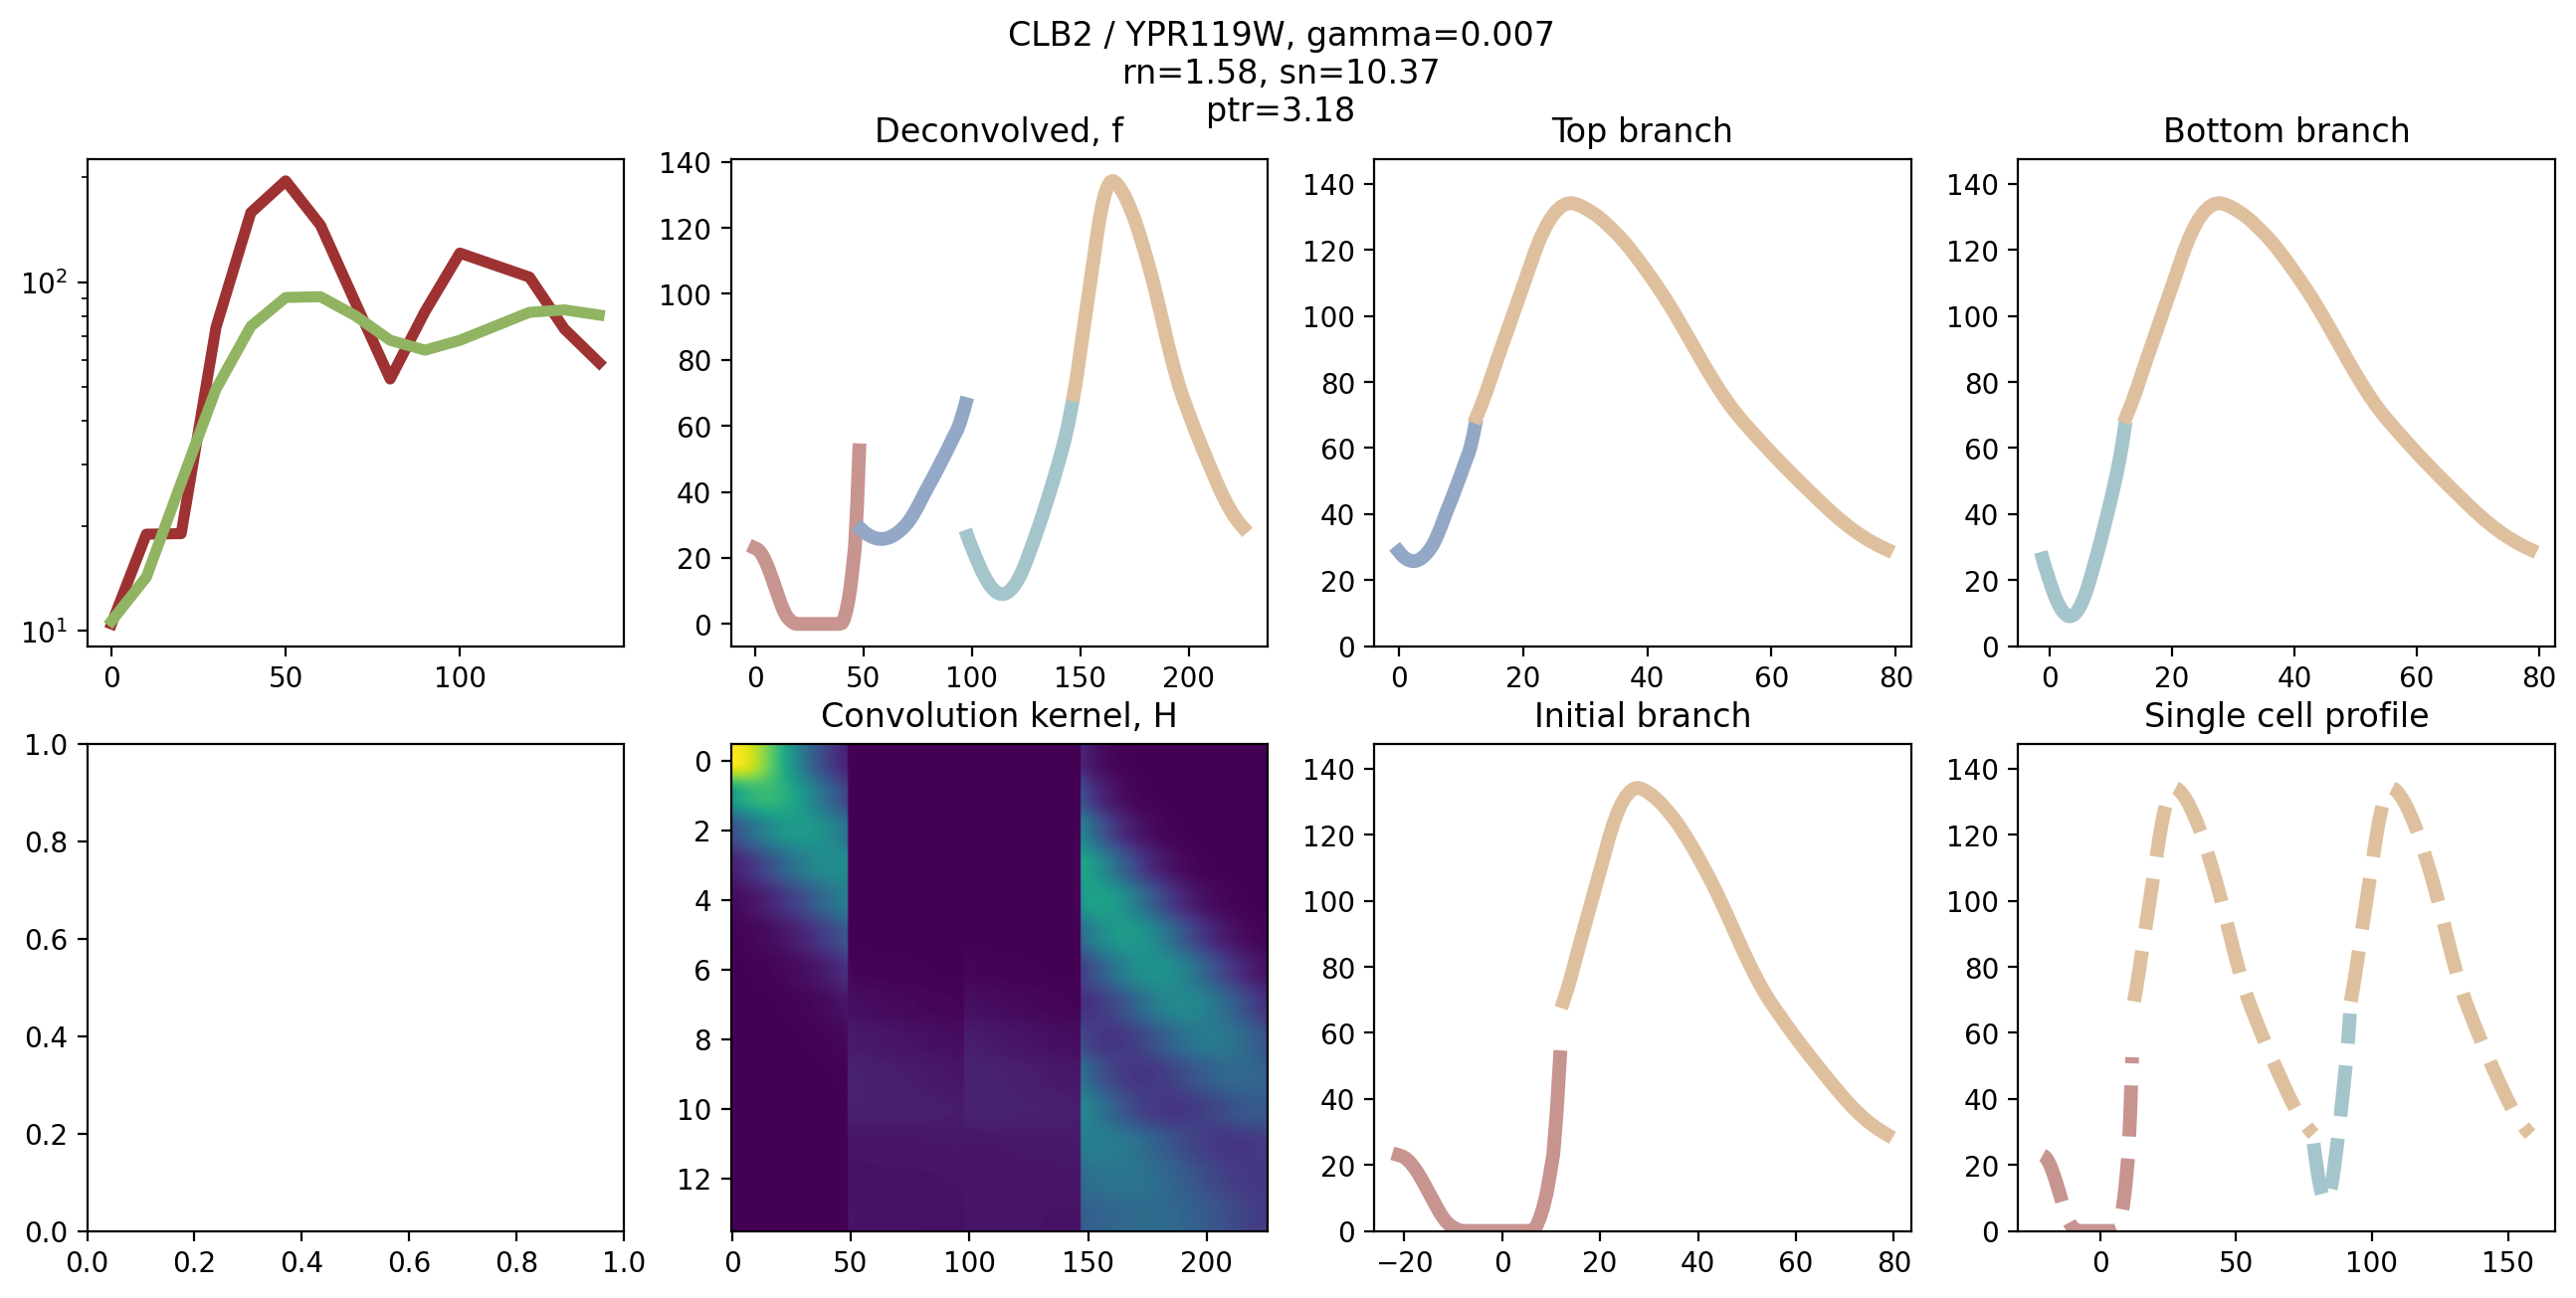

In [33]:
model.plot_deconvolved_gene()